In [1]:
from manim import *
import numpy as np
import random
config.media_width = "75%"
config.verbosity = "WARNING"

heading_gradient_colors = ["#03fcca", "#f21de8"]
#gradient_colors = ["#D4145A", "#FBB03B"]
#gradient_colors = ["#009245", "#FCEE21"]
gradient_colors = ["#FF512F", "#DD2476"]

#primary = "#DE286F"
primary = "#58C4DD"

secondary = "#FC6255"

tertiary = "#83C167"

grid_color = "#5CD0B3"

highlight_color = "#029782"

In [9]:
%%manim -qh S1

class S1(Scene):
    def construct(self):
        # Load the SVG file
        svg = SVGMobject("Isoperimetric_inequality_illustr1.svg")
        svg.set(width=8)  # Resize if needed
        svg.center()

        # Optionally ungroup elements for individual animations
        elms = svg.submobjects
        
        elms[0].set_color(GREEN)
        elms[1].set_color(GREEN)

        title = Tex(r"Which curve of fixed length has the greatest area?", font_size=50).to_edge(UP)

        length = Tex(r"Length: $\ell$", font_size=55).move_to(UP*2 + LEFT*4.5)
        area = Tex(r"Enclosed area: $\mathcal{A}$", font_size=55).move_to(UP*1.3 + LEFT*4.5)
        curve = VGroup(elms[0], elms[1]).copy()


        self.play(FadeIn(curve[0]))
        self.wait()
        self.play(FadeIn(area, length))
        self.wait()
        self.play(Write(title))
        self.wait()
        self.play(FadeIn(curve[1]))
        self.wait()

        circle = Circle(radius=3, color=GREEN, fill_opacity=0.6).shift(DOWN*0.7)
        self.play(FadeOut(area, length), ReplacementTransform(curve, circle))
        self.wait()

        circ1 = MathTex(r"\ell = 2\pi r", font_size=55).move_to(LEFT*4.5 + UP*2)
        circ2 = MathTex(r"\mathcal{A} = \pi r^2 \\= \frac{\ell^2}{4 \pi}", font_size=55).move_to(LEFT*4.5 + DOWN)
        self.play(Write(circ1))
        self.wait()
        self.play(Write(circ2))
        self.wait()
        
        circ3 = MathTex(r"\mathcal{A} = \frac{\ell^2}{4 \pi}").move_to(LEFT*5 + DOWN*2)
        self.play(FadeOut(circ1), ReplacementTransform(circ2, circ3), circle.animate.scale(0.4).move_to(LEFT*5 + DOWN*2))
        self.wait()

        elms[0].scale(0.3).move_to(UP*1.75)
        isop = Tex(r"Isoperimetric Inequality: $\mathcal{A} \le \frac{\ell^2}{4\pi}$", font_size=55).next_to(elms[0], DOWN)
        self.play(FadeIn(elms[0]))
        self.play(Write(isop))
        self.wait()
        iff = MathTex(r"\Leftrightarrow", font_size=65).move_to(DOWN*2)
        self.play(circ3.animate.next_to(iff, LEFT))
        self.play(FadeIn(iff))
        self.play(circle.animate.next_to(iff, RIGHT))
        self.wait()
        self.play(FadeOut(title, elms[0], isop, circ3, iff, circle))

Manim Community v0.19.0

Manim Community v0.19.0

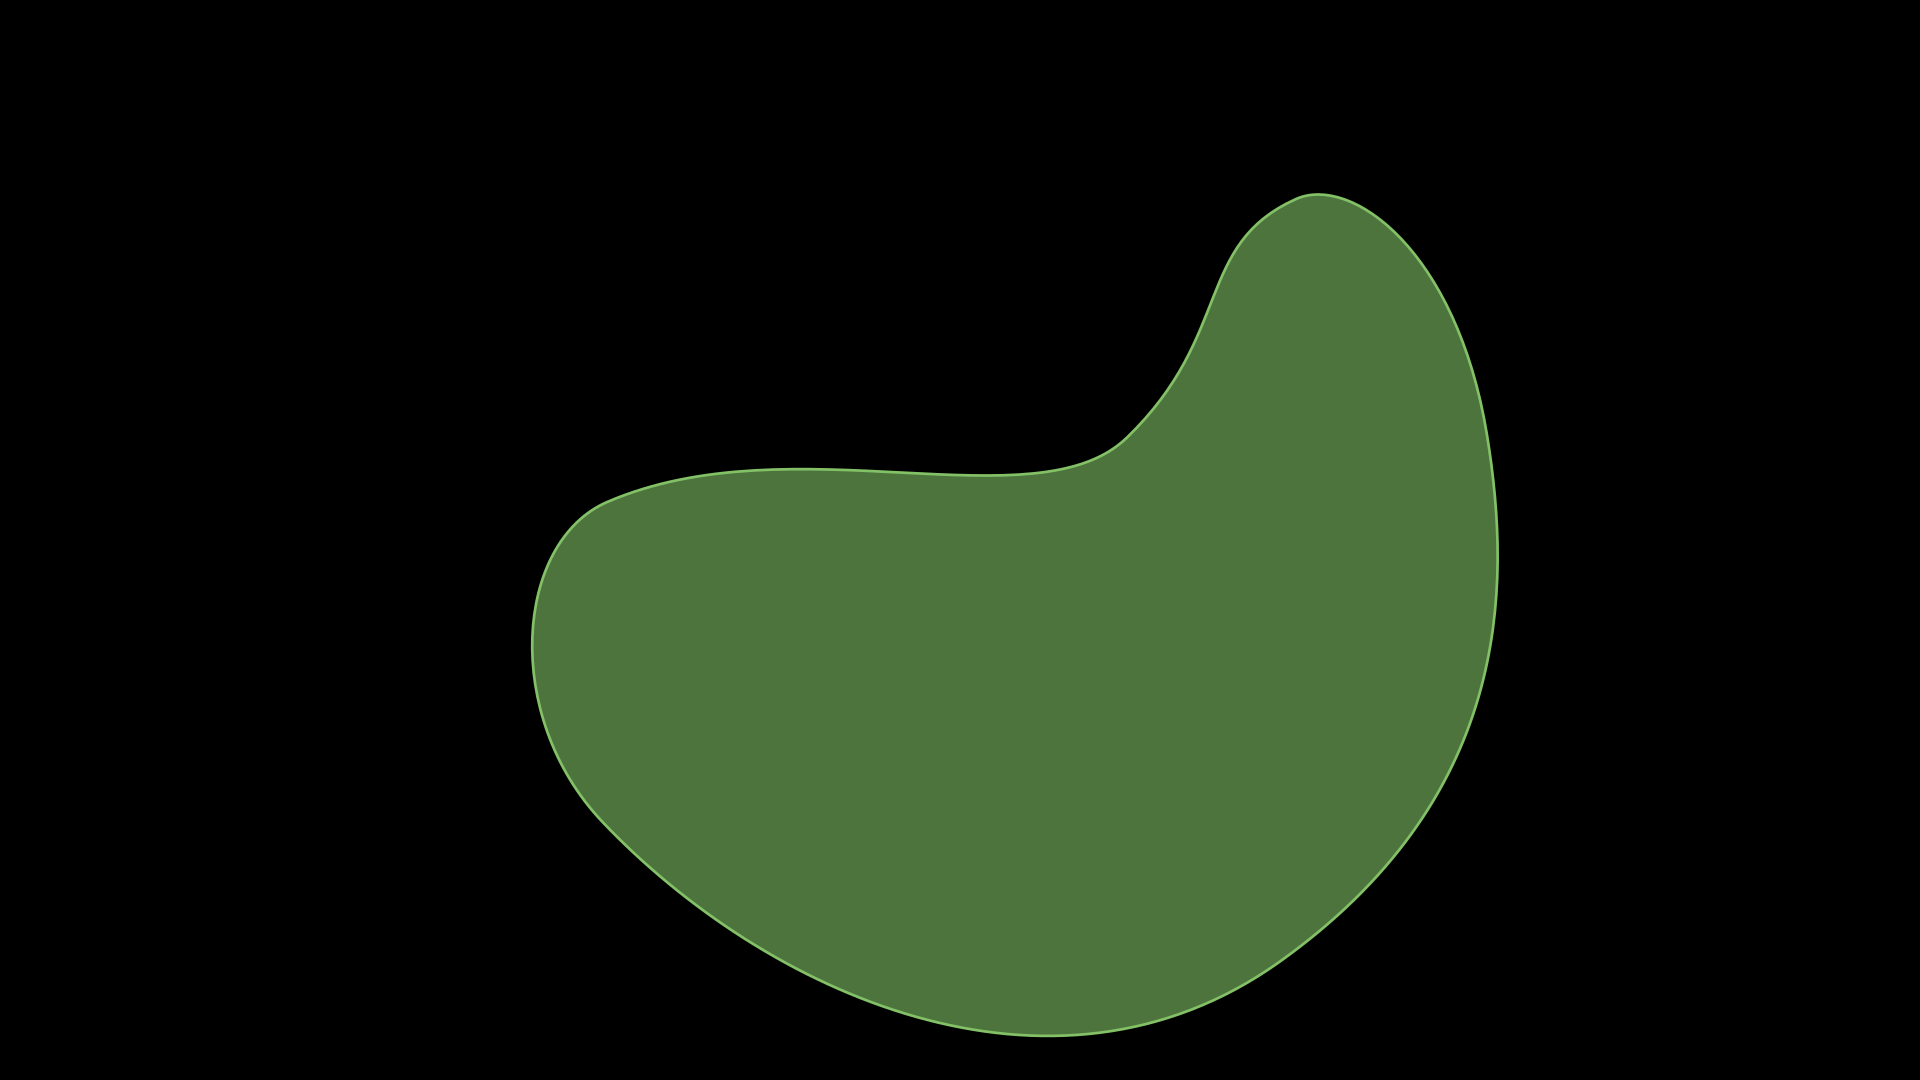

In [3]:
%%manim -qh thumb1

class thumb1(Scene):
    def construct(self):
        # Load the SVG file
        svg = SVGMobject("Isoperimetric_inequality_illustr1.svg")
        svg.set(width=8)  # Resize if needed
        svg.center()

        # Optionally ungroup elements for individual animations
        elms = svg.submobjects
        
        elms[0].set_color(GREEN)
        elms[1].set_color(GREEN)

        title = Tex(r"Which curve of fixed length has the greatest area?", font_size=50).to_edge(UP)

        length = Tex(r"Length: $\ell$", font_size=55).move_to(UP*2 + LEFT*4.5)
        area = Tex(r"Enclosed area: $\mathcal{A}$", font_size=55).move_to(UP*1.3 + LEFT*4.5)
        curve = VGroup(elms[0], elms[1]).copy()


        self.add(curve[0])

Manim Community v0.19.0

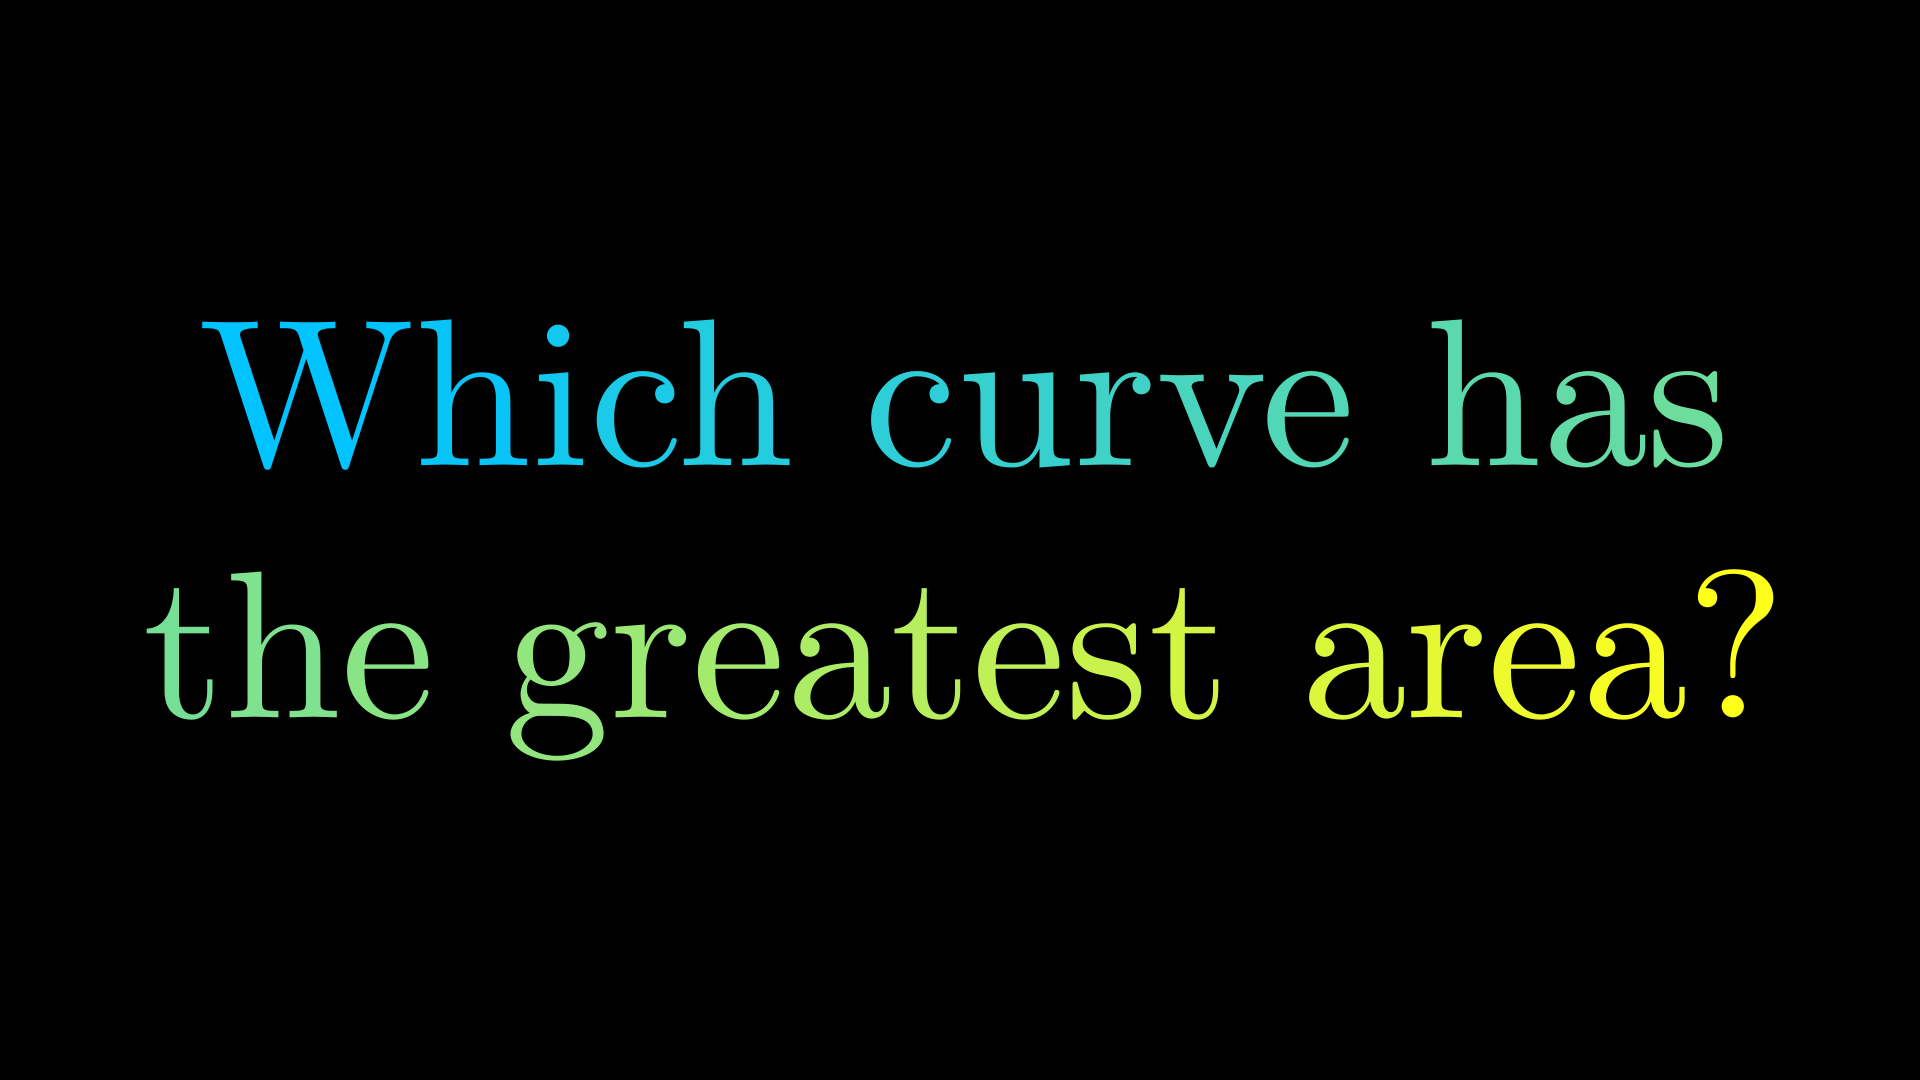

In [10]:
%%manim -qh thumb2

class thumb2(Scene):
    def construct(self):
        title = Tex(r"Which curve has \\ the greatest area?", font_size=150).set_color_by_gradient("#00c3ff", "#ffff1c")
        self.add(title)

In [14]:
%%manim -qh S15

class S15(Scene):
    def construct(self):
        # Axes covering multiple periods
        axes = Axes(
            x_range=[-2*PI, 2*PI, PI],  # show -2π to 2π
            y_range=[-2, 2, 1],
            x_length=12,
            y_length=4
        ).shift(UP*1.5)

        parsetex = Tex(r"Parseval's theorem").move_to(DOWN*1.5).set_color(BLUE)
        
        # Parseval's theorem
        parse = MathTex(r"\frac{1}{\ell} \int_0^\ell f \overline{g} = \sum_{n=-\infty}^\infty \hat f(n) \overline{\hat g(n)}")
        parse.next_to(parsetex, DOWN).shift(LEFT*3.5)
        parse2 = MathTex(r"\frac{1}{\ell} \int_0^\ell |f|^2 = \sum_{n=-\infty}^\infty |\hat f(n)|^2")
        parse2.next_to(parsetex, DOWN).shift(RIGHT*3.5)

        self.add(parsetex, parse, parse2)

        

        # Define a smooth periodic function: f(x) = sin(x) + 0.5*sin(3x)
        def func(x):
            return np.sin(x) -0.1*np.sin(2*x) + 0.5*np.sin(3*x) -0.3*np.sin(4*x)

        func_graph = axes.plot(func, color=YELLOW)
        #func_label = axes.get_graph_label(func_graph, label="f(x)", x_val=PI/2, direction=UP)

        self.add(axes, func_graph)
        self.wait(1)

        # Fourier coefficients for f(x)
        # f(x) = sin(x) + 0.5*sin(3x)
        def fourier_series(x, n_terms=1):
            result = 0
            # compute sine series up to n_terms
            for k in range(1, n_terms + 1):
                if k == 1:
                    result += np.sin(x)   # coefficient = 1
                elif k == 2:
                    result += -0.1*np.sin(2*x)
                elif k == 3:
                    result += 0.5*np.sin(3*x)  # coefficient = 0.5
                elif k == 4:
                    result += -0.3*np.sin(4*x)
                # Other terms are zero, but kept for clarity
            return result

        colors = [RED, GREEN, ORANGE, PURPLE, PINK]

        approx_graphs = []
        # Show Fourier approximations with 1, 2, 3 terms...
        for i, n in enumerate([1, 2, 3, 4]):
            graph = axes.plot(lambda x: fourier_series(x, n_terms=n), color=colors[i % len(colors)])
            label = MathTex(f"S_{n}(x)").next_to(axes, UP+RIGHT).set_color(colors[i % len(colors)])

            if i == 0:
                self.play(Create(graph))
                g2 = graph
            else:
                self.play(Transform(g2, graph))

            #approx_graphs.append(graph)
            self.wait(0.5)

        self.wait(0.5)

Manim Community v0.19.0

In [10]:
%%manim -qh S2

class S2(Scene):
    def construct(self):
        defcurve = Tex(r"parametric curve: continuous map $\gamma: [a,b] \to \mathbb{R}^2$").to_edge(UP)
        defsim = Tex(r"simple (no self-intersections) and closed curve").to_edge(DOWN)
        deri = MathTex(r"\gamma(t)", r" = (x(t), y(t)) \\", r"\gamma'(t)", r" = (x'(t), y'(t))").move_to(UP*2 + RIGHT*4)
        deri[0].set_color(YELLOW)
        deri[2].set_color(RED)
        
        # Define the interval
        a, b = 0, 2 * PI

        # Define the parametric functions
        def x(t): return 2 * np.cos(t)
        def y(t): return np.sin(t)
        def dx(t): return -2 * np.sin(t)
        def dy(t): return np.cos(t)

        # Parametric curve function
        def param_func(t): return np.array([x(t), y(t), 0])

        # Create the curve
        curve = ParametricFunction(param_func, t_range=[a, b], color=BLUE)

        # Add coordinate axes
        axes = Axes(
            x_range=[-3, 3],
            y_range=[-1.25, 1.25],
            axis_config={"include_tip": False}
        )

        # Dot for point on the curve
        moving_dot = Dot(color=YELLOW).move_to(param_func(a))

        # Tangent vector
        def tangent_vector(t):
            dx_val, dy_val = dx(t), dy(t)
            vec = np.array([dx_val, dy_val, 0])
            vec_norm = vec / np.linalg.norm(vec)
            return Arrow(start = param_func(t), end = param_func(t)+vec, buff=0, color=RED)
            #return Vector(vec_norm, color=RED).scale(0.7).move_to(param_func(t))

        t_tracker = ValueTracker(a)

        tangent = always_redraw(lambda: tangent_vector(t_tracker.get_value()))

        # Time tracker

        # Update moving dot position
        moving_dot.add_updater(lambda m: m.move_to(param_func(t_tracker.get_value())))

        # Add everything to the scene
        self.play(Create(axes))
        self.play(Create(curve), Write(defsim))
        self.wait()
        self.play(FadeIn(defcurve))
        self.wait()
        self.play(FadeIn(deri, moving_dot, tangent))
        self.play(t_tracker.animate.set_value(b), run_time=8, rate_func=linear)
        t_tracker.set_value(a)
        self.play(t_tracker.animate.set_value(b), run_time=8, rate_func=linear)
        self.wait()
        self.play(FadeOut(axes, curve, defsim, defcurve, deri, moving_dot, tangent))

Manim Community v0.19.0

In [11]:
%%manim -qh S3

class S3(Scene):
    def construct(self):
        iden = Tex(r"Identify $\mathbb{R}^2$ with $\mathbb{C}$, $\gamma: [a,b] \to \mathbb{C}$").to_edge(UP)
        defl = MathTex(r"\ell = \int_a^b \sqrt{x'(t)^2 + y'(t)^2} \,dt", r" = \int_a^b |\gamma'|")
        defA = MathTex(r"\mathcal{A} = \frac{1}{2}\int_a^b x(s)y'(s) - y(s)x'(s)\,ds", r"= \frac{1}{2i} \int_a^b \overline{\gamma}\gamma'")

        defl.move_to(UP*1.3)
        defA.move_to(DOWN*1.3)

        self.play(Write(defl[0]))
        self.play(Write(defA[0]))
        self.wait()
        self.play(FadeIn(iden))
        self.wait()
        self.play(Write(defl[1]), Write(defA[1]))
        self.wait()
        self.play(FadeOut(iden, defl, defA))

Manim Community v0.19.0

In [12]:
%%manim -qh S4

class S4(Scene):
    def construct(self):
        title = Tex("Different Parametrizations of the Same Curve").to_edge(UP)
        self.play(Write(title))

        # Left curve (nonlinear parametrization)
        left_circle = Circle(radius=2, color=BLUE).shift(LEFT*3 + UP*0.5)
        left_label = Tex("Nonlinear parametrization", font_size=35).next_to(left_circle, DOWN)

        # Right curve (arc-length parametrization)
        right_circle = Circle(radius=2, color=BLUE).shift(RIGHT*3 + UP*0.5)
        right_label = Tex("Arc-length parametrization", font_size=35).next_to(right_circle, DOWN)

        ded1 = MathTex(r"|\gamma'(t)| = 1 \; \forall t \in [a,b]", font_size=40)
        ded1.next_to(right_label, DOWN)
        right_label = VGroup(right_label, ded1)

        self.play(Create(left_circle), Create(right_circle))
        self.play(Write(left_label), Write(right_label))

        # Dots
        dot1 = Dot(color=YELLOW).move_to(left_circle.point_from_proportion(0))
        dot2 = Dot(color=RED).move_to(right_circle.point_from_proportion(0))

        self.play(FadeIn(dot1), FadeIn(dot2))

        # Animate the two dots
        # Left: nonlinear speed (accelerates then decelerates, but never goes back)
        # Right: uniform speed (arc-length)
        self.play(
            MoveAlongPath(dot1, left_circle, rate_func=smooth, run_time=6),   # non-uniform speed
            MoveAlongPath(dot2, right_circle, rate_func=linear, run_time=6),  # uniform speed
        )

        self.wait(2)

        self.play(FadeOut(dot1, left_circle, left_label))

        len1 = MathTex(r"\ell = \int_a^b |\gamma '| = b - a").move_to(LEFT*3.5 + UP*1.5)
        len2 = Tex(r"extend $\gamma$ to \\ $\ell$-periodic function \\ $\gamma: \mathbb{R} \to \mathbb{C}$").move_to(LEFT*3.5 + DOWN*1.5)
        len3 = Tex(r"(since $\gamma(a) = \gamma(b)$)").next_to(len2, DOWN)
        self.play(Write(len1))
        self.wait()
        self.play(Write(len2))
        self.play(Write(len3))
        self.wait()
        self.play(FadeOut(title, len1, len2, len3, right_label, right_circle, dot2))


Manim Community v0.19.0

In [13]:
%%manim -qh S5

class S5(Scene):
    def construct(self):
        setup = Tex(r"$f,g: \mathbb{R} \to \mathbb{C}$ are $\ell$-periodic continuous").to_edge(UP)

        fourtex = Tex(r"Fourier coefficients").set_color(RED).next_to(setup, DOWN).shift(DOWN*0.5)

        four = MathTex(r"\hat{f}(n) \;=\; \frac{1}{\ell} \int_{0}^{\ell} f(x)\, e^{- i \frac{2\pi n}{\ell} x}\, dx")
        four.next_to(fourtex, DOWN).shift(LEFT*3)

        deri = MathTex(r"\widehat{f'}(n) = i \frac{2\pi n}{\ell} \hat f(n)").next_to(fourtex, DOWN).shift(RIGHT*4.5)


        parsetex = Tex(r"Parseval's theorem").move_to(DOWN*1).set_color(BLUE)
        
        # Parseval's theorem
        parse = MathTex(r"\frac{1}{\ell} \int_0^\ell f \overline{g} = \sum_{n=-\infty}^\infty \hat f(n) \overline{\hat g(n)}")
        parse.next_to(parsetex, DOWN).shift(LEFT*3.5)
        parse2 = MathTex(r"\frac{1}{\ell} \int_0^\ell |f|^2 = \sum_{n=-\infty}^\infty |\hat f(n)|^2")
        parse2.next_to(parsetex, DOWN).shift(RIGHT*3.5)

        self.play(FadeIn(setup))
        self.play(FadeIn(fourtex))
        self.play(Write(four), Write(deri))
        self.wait()
        self.play(FadeIn(parsetex))
        self.play(Write(parse), Write(parse2))
        self.wait()
        self.play(FadeOut(setup, fourtex, four, deri, parsetex, parse, parse2))

Manim Community v0.19.0

In [14]:
%%manim -qh S6

class S6(Scene):
    def construct(self):
        # Load the SVG file
        svg = SVGMobject("Isoperimetric_inequality_illustr1.svg")
        svg.set(width=8)  # Resize if needed
        svg.center()

        # Optionally ungroup elements for individual animations
        elms = svg.submobjects
        
        elms[0].set_color(GREEN)
        elms[1].set_color(GREEN)

        title = Tex(r"Let $\gamma$ be a simple closed curve parametrized by arc-length.", font_size=50).to_edge(UP)

        curve = VGroup(elms[0], elms[1]).copy()



        circle = Circle(radius=3, color=GREEN, fill_opacity=0.6).shift(DOWN*0.7)

        circ1 = MathTex(r"\ell = 2\pi r", font_size=55).move_to(LEFT*4.5 + UP*2)
        circ2 = MathTex(r"\mathcal{A} = \pi r^2 \\= \frac{\ell^2}{4 \pi}", font_size=55).move_to(LEFT*4.5 + DOWN)
        
        circ3 = MathTex(r"\mathcal{A} = \frac{\ell^2}{4 \pi}").move_to(LEFT*5 + DOWN*2)
        circle.scale(0.4).move_to(LEFT*5 + DOWN*2)
        

        elms[0].scale(0.3).move_to(UP*1.75)
        isop = Tex(r"Isoperimetric Inequality: $\mathcal{A} \le \frac{\ell^2}{4\pi}$", font_size=55).next_to(elms[0], DOWN)
        iff = MathTex(r"\Leftrightarrow", font_size=65).move_to(DOWN*2)
        circ3.next_to(iff, LEFT)
        circle.next_to(iff, RIGHT)
        self.play(FadeIn(title, elms[0], isop, circ3, iff, circle))
        self.wait()

        self.play(FadeOut(elms[0], isop, circ3, iff, circle))

        equ1 = MathTex(
            r"\frac{4\pi}{\ell^2} \mathcal{A}", r"= \frac{4\pi}{\ell^2} \frac{1}{2i} \int_0^\ell \overline{\gamma} \gamma'",            
            r"= \frac{2\pi}{\ell i} \sum_{n=-\infty}^\infty \overline{\hat \gamma (n)} \cdot i \frac{2\pi n}{\ell} \hat \gamma(n)",
            r" = \sum_{n=-\infty}^\infty n \left| \frac{2\pi}{\ell} \hat\gamma(n) \right|^2 ",
            r"\stackrel{(n \le n^2)}{\le}", r" \sum_{n=-\infty}^\infty \left| \frac{2\pi n}{\ell} \hat\gamma(n) \right|^2", 
            r"= \frac{1}{\ell}\int_0^\ell |\gamma'|^2 = ", r"1 "
        ).shift(UP)

        fourtex = Tex(r"Fourier coefficients").set_color(RED).move_to(LEFT * 3.5 + DOWN)
        deri = MathTex(r"\widehat{f'}(n) = i \frac{2\pi n}{\ell} \hat f(n)").next_to(fourtex, DOWN)
        fgrou = VGroup(fourtex, deri)
        
        parsetex = Tex(r"Parseval's theorem").move_to(DOWN*1 + RIGHT*3.5).set_color(BLUE)
        parse = MathTex(r"\frac{1}{\ell} \int_0^\ell f \overline{g} = \sum_{n=-\infty}^\infty \hat f(n) \overline{\hat g(n)}")
        parse.next_to(parsetex, DOWN)
        pgrou = VGroup(parsetex, parse)

        equ1[0].move_to(UP)
        self.play(FadeIn(equ1[0]))
        self.wait()
        self.play(equ1[0].animate.shift(LEFT*1.5))
        equ1[1].next_to(equ1[0], RIGHT)
        self.play(Write(equ1[1]))
        self.wait()
        self.play(FadeIn(fgrou, pgrou))
        self.wait()

        self.play(equ1[0:2].animate.shift(LEFT*3.5))
        equ1[2].next_to(equ1[0:2], RIGHT)
        self.play(Write(equ1[2]))
        self.wait()

        self.play(FadeOut(equ1[1]), equ1[2].animate.next_to(equ1[0]))
        equ1[3].next_to(equ1[2])
        self.play(FadeIn(equ1[3]), FadeOut(fgrou, pgrou))
        self.wait()
        self.play(FadeOut(equ1[2]), equ1[3].animate.next_to(equ1[0]))
        

        equ1[4:6].next_to(equ1[3], RIGHT)
        self.play(FadeIn(equ1[4:6]))
        self.wait()

        equiff = Tex(r"Equality, iff ", r"$\hat \gamma (n) = 0 \; \forall n \ne 0, 1$").move_to(DOWN*2.5)
        self.play(FadeIn(equiff))
        self.wait()

        self.play(FadeOut(equ1[3]), equ1[4:6].animate.next_to(equ1[0]))
        equ1[6:].next_to(equ1[5], RIGHT)
        self.play(Write(equ1[6:]))
        self.wait()

        final = MathTex(r"\mathcal{A} ", r"\le", r"\frac{\ell^2}{4 \pi}").move_to(DOWN*1)
        rect = SurroundingRectangle(final, color=YELLOW)
        self.play(ReplacementTransform(VGroup(equ1[0], equ1[6]).copy(), final))
        self.play(Create(rect))
        self.wait()
        
        finalequ = MathTex(r"\mathcal{A} ", r"=", r"\frac{\ell^2}{4 \pi}").move_to(DOWN*1)
        self.play(Transform(final[1], finalequ[1]))
        finalg = VGroup(final, rect)
        self.wait()
        self.play(finalg.animate.shift(LEFT*5))

        brace = Brace(equ1[5], sharpness = 1)
        bracetex = MathTex(r"= \left|\frac{2\pi}{\ell} \hat \gamma(1)\right|^2").next_to(brace, DOWN)
        self.play(Create(brace))
        self.play(Write(bracetex))
        self.wait()

        imp = MathTex(r"\Rightarrow |\hat\gamma(1)| = \frac{\ell}{2\pi}, ", r"\hat\gamma(1) = \frac{\ell}{2\pi} e^{i \varphi}").next_to(bracetex, RIGHT)
        self.play(FadeIn(imp))
        self.wait()
        
        self.play(FadeOut(title, equ1[0], equ1[4:], brace, bracetex, imp[0]), finalg.animate.move_to(UP*2.75 + LEFT*4.5), imp[1].animate.move_to(UP*2.75 + RIGHT*4.5))
        signiff = MathTex(r"\Leftrightarrow").next_to(finalg, RIGHT)
        self.play(FadeIn(signiff))
        self.play(FadeOut(equiff[0]), equiff[1].animate.next_to(signiff, RIGHT))
        self.wait()

        head = VGroup(finalg, signiff, equiff[1], imp[1])
        theo = Tex(r"If $f:\mathbb{R} \to \mathbb{C}$ is a continuous, $\ell$-periodic function \\ such that $\hat f(n) = 0$ for almost every $n$, \\ then $f$ is equal to its Fourier series, \\ meaning $f(x) = \sum_{n=-\infty}^\infty \hat f(n) e^{i \frac{2\pi n}{\ell} x}$")
        con = MathTex(r"\gamma(t) = \hat \gamma(0) + \hat \gamma(1) e^{i\frac{2\pi}{\ell} t} = a + \frac{\ell}{2\pi} e^{\varphi + i \frac{2\pi}{\ell}t}")
        con.move_to(DOWN*2.5)
        con2 = Tex(r"$\gamma$ is a circle of radius $\frac{\ell}{2\pi}$.").next_to(con, DOWN)

        self.play(FadeIn(theo))
        self.wait()
        self.play(Write(con))
        self.wait()
        self.play(Write(con2))
        self.wait()
        self.play(FadeOut(theo, con, con2, head))
        self.play(FadeIn(title, elms[0], isop, circ3, iff, circle))
        self.wait(3)
        self.play(FadeOut(title, elms[0], isop, circ3, iff, circle))
        

Manim Community v0.19.0